### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading the dataset and basic data understanding

In [8]:
df = pd.read_csv(r"E:\airbnb_trans",).iloc[:, 1:] 
df.head()

,Price,review,rating,Location,No_of_beds,bed_type,badge,property_type,Title
0,1952.0,10.0,5.00,Surat,2,single,guest favourite,Flat/Apartment,Stay zen at weekend address
1,2283.0,174.0,4.74,Surat,1,double,host,Flat/Apartment,"VHHS studio apartment, Surat Airport 2"
2,2739.0,76.0,4.84,Surat,2,single,guest favourite,Flat/Apartment,Lovely 2 bedroom service apartment with pool
3,1370.0,8.0,4.75,Surat,1,double,host,hotel,Hotel Serene Stay
4,2260.0,42.0,4.88,Surat,2,single,guest favourite,Bungalow/Guest house,Belgium Service Apartment - (In Commercial space)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          401 non-null    float64
 1   review         401 non-null    float64
 2   rating         401 non-null    float64
 3   Location       401 non-null    object 
 4   No_of_beds     401 non-null    int64  
 5   bed_type       401 non-null    object 
 6   badge          401 non-null    object 
 7   property_type  401 non-null    object 
 8   Title          401 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 28.3+ KB


In [10]:
df.describe()

,Price,review,rating,No_of_beds
count,401.000000,401.000000,401.000000,401.000000
mean,5114.335411,14.615960,4.497687,2.466334
std,3346.600902,23.682423,0.824553,2.799909
min,918.000000,0.000000,0.000000,1.000000
25%,2499.000000,0.000000,4.497687,1.000000
50%,4119.000000,5.000000,4.560000,2.000000
75%,6678.000000,17.000000,4.850000,3.000000
max,12946.500000,174.000000,5.000000,44.000000


In [11]:
df.shape

(401, 9)

## Data Cleaning

In [12]:
df.isnull().sum()

Price            0
review           0
rating           0
Location         0
No_of_beds       0
bed_type         0
badge            0
property_type    0
Title            0
dtype: int64

### Statistical Analysis of continuos variable - Price

In [14]:
df['Price'].describe()


count      401.000000
mean      5114.335411
std       3346.600902
min        918.000000
25%       2499.000000
50%       4119.000000
75%       6678.000000
max      12946.500000
Name: Price, dtype: float64

In [16]:
print(df['Price'].skew())
print(df['Price'].kurtosis())
-- here skewness is greater than 0 signifies its not normal distribution 
-- 

1.0636641375024818
0.20157556158648715


## Outlier Detection

In [18]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[df['Price'] > Q3 + 1.5*IQR]


### Correlation between numeric columns

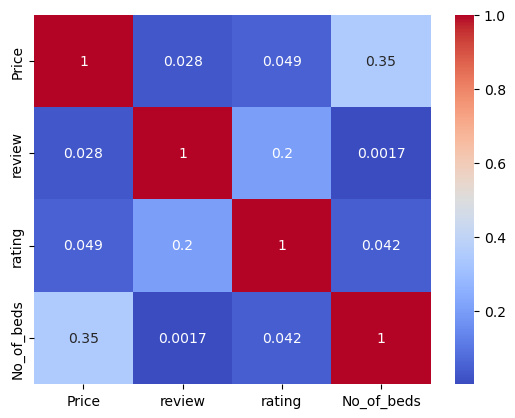

In [20]:
num_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.show()


### Visualization - univariate analysis 

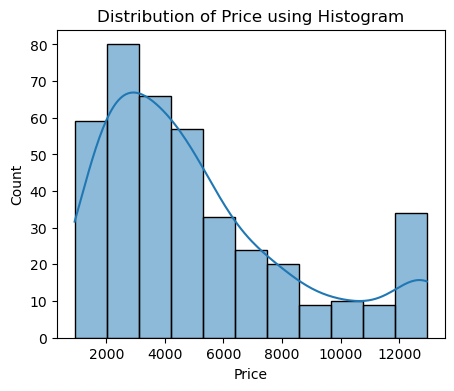

In [29]:
plt.figure(figsize=(5,4))
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Price using Histogram")
plt.show()

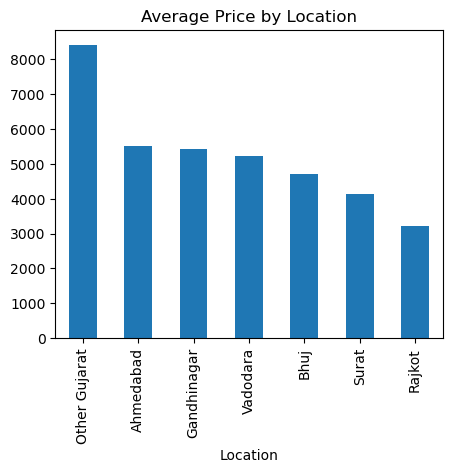

In [28]:
plt.figure(figsize=(5,4))
df.groupby('Location')['Price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average Price by Location")
plt.show()

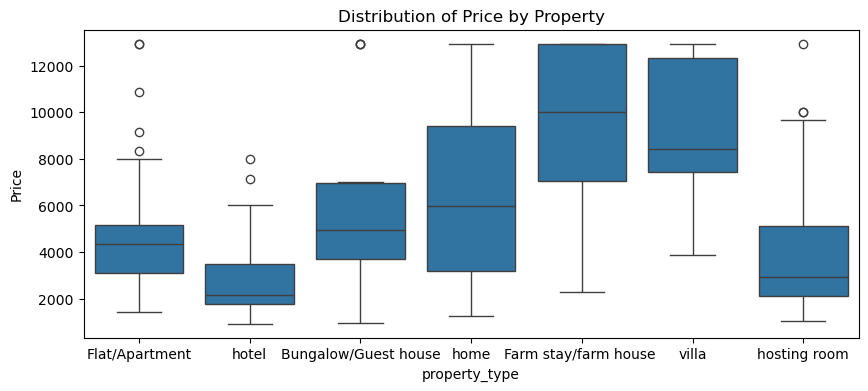

In [34]:
plt.figure(figsize=(10,4))
sns.boxplot(x="property_type", y="Price", data=df)
plt.title("Distribution of Price by Property")
plt.show()

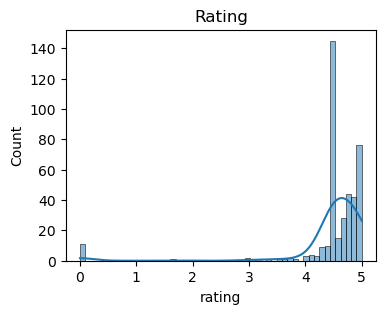

In [39]:
plt.figure(figsize=(4,3))
sns.histplot(df['rating'], kde=True)
plt.title("Rating")
plt.show()

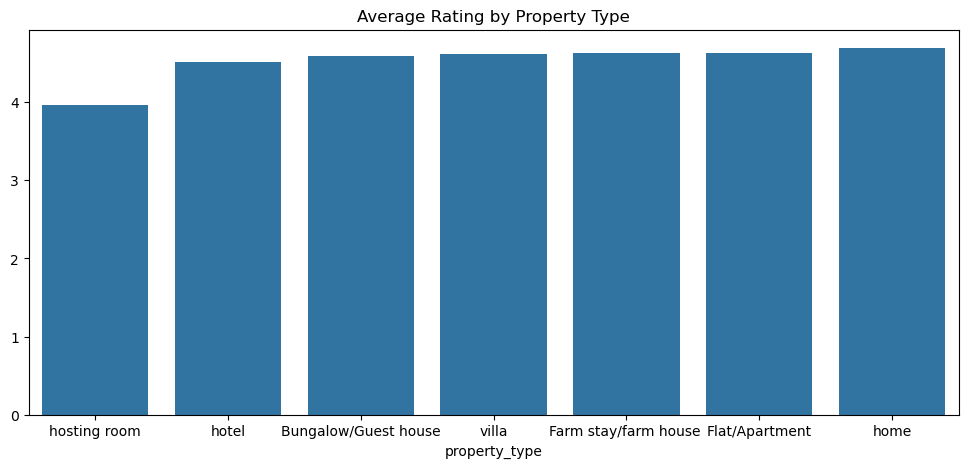

In [45]:
avg_rating = df.groupby("property_type")["rating"].mean().sort_values()

plt.figure(figsize=(12,5))
sns.barplot(x=avg_rating.index, y=avg_rating.values)
plt.title("Average Rating by Property Type")
plt.show()


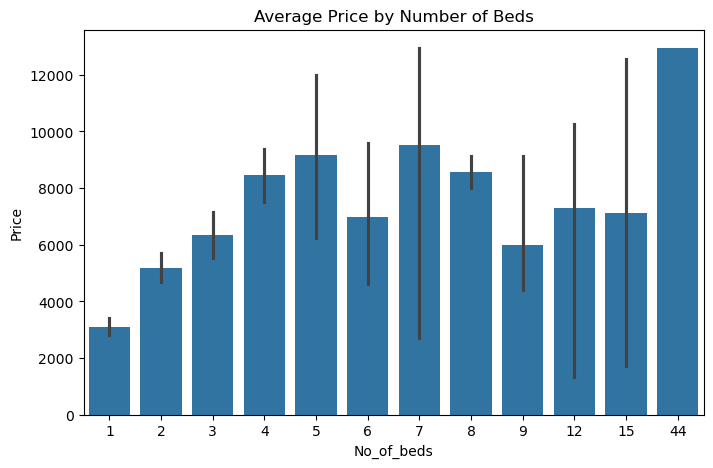

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="No_of_beds", y="Price")
plt.title("Average Price by Number of Beds")
plt.show()


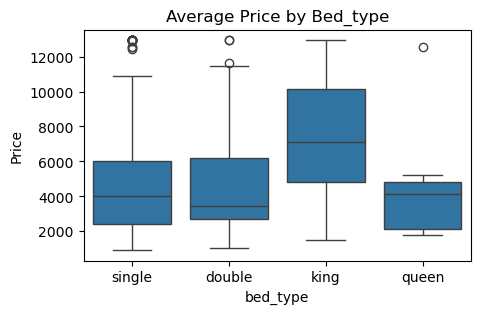

In [55]:
plt.figure(figsize=(5,3))
sns.boxplot(data=df, x="bed_type", y="Price")
plt.title("Distribution of Price by Bed_type")
plt.show()

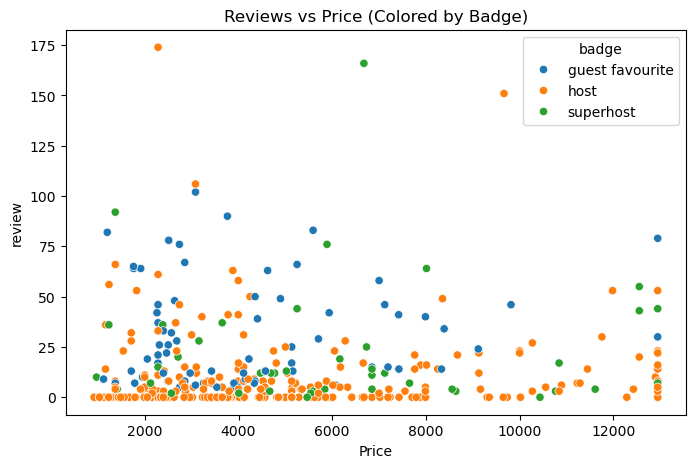

In [57]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Price",y="review",hue="badge")
plt.title("Reviews vs Price (Colored by Badge)")
plt.show()


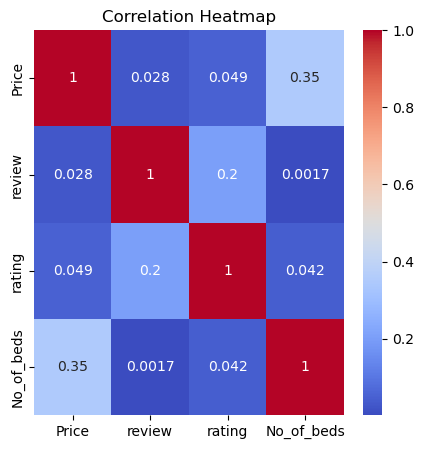

In [62]:
num_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(5,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


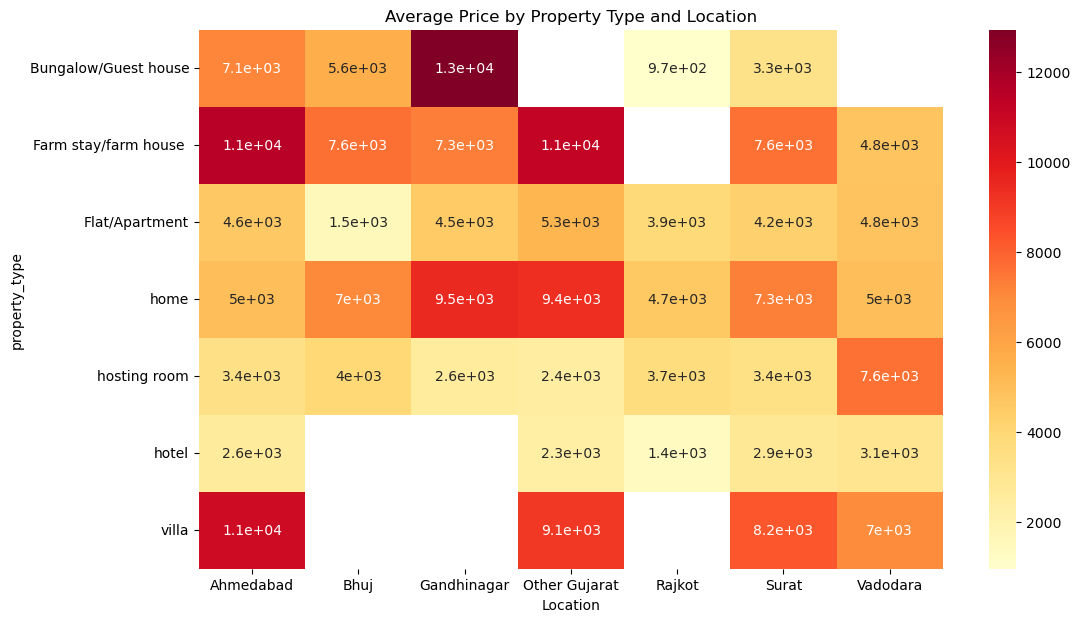

In [64]:
pivot = df.pivot_table(values="Price", index="property_type", columns="Location", aggfunc="mean")
plt.figure(figsize=(12,7))
sns.heatmap(pivot, annot=True, cmap="YlOrRd")
plt.title("Average Price by Property Type and Location")
plt.show()
